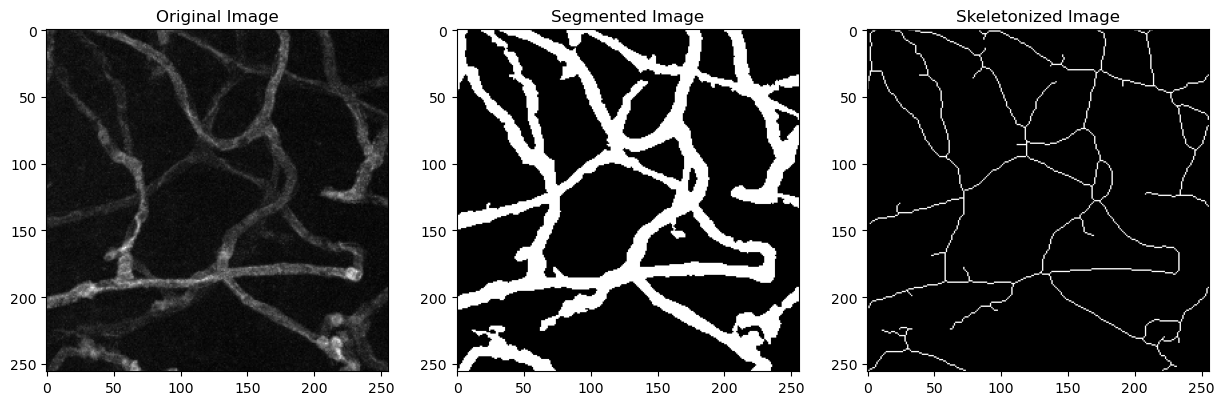

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from pyvane.graph.creation import create_graph, create_graph_with_mapping
from pyvane.segmentation import local_threshold
from pyvane.skeletonization import lee
from pyvane.util.misc import graph_to_img

file_path = "../data/vessmap_examples/images/12749.tiff"
img = np.array(Image.open(file_path))

bin_img = local_threshold.vessel_segmentation(img, threshold=0, sigma=1, radius=40, comp_size=100, hole_size=30)
skel_img = lee.skeletonize(bin_img)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img, cmap="gray")
axs[0].set_title("Original Image")
axs[1].imshow(bin_img, cmap="gray")
axs[1].set_title("Segmented Image")
axs[2].imshow(skel_img, cmap="gray")
axs[2].set_title("Skeletonized Image")
plt.show()

Text(0.5, 1.0, 'Graph Visualization')

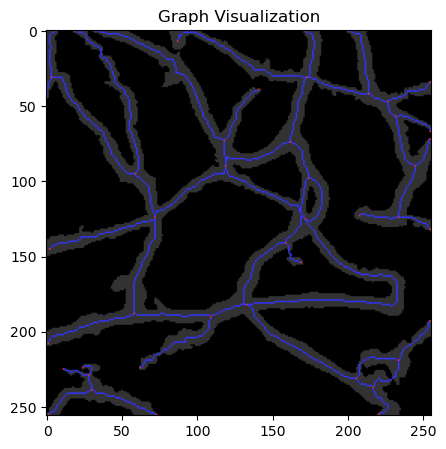

In [2]:
graph = create_graph(skel_img, bin_img, length_threshold=10) 

graph_img = graph_to_img(
    graph, 
    img_shape=img.shape, 
    node_color=(255, 0, 0),
    node_pixels_color=(0, 0, 0), 
    edge_color=(0, 0, 255)
    )

plt.figure(figsize=(5, 5))
plt.imshow(graph_img)
plt.imshow(bin_img, cmap="gray", alpha=0.2)
plt.title("Graph Visualization")

## Assignment of vessel segments to graph nodes and edges

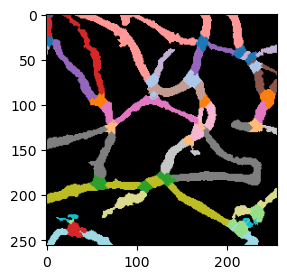

In [5]:
graph, labeled_volume, mappings = create_graph_with_mapping(skel_img, bin_img, length_threshold=10)

cmap = plt.get_cmap("tab20").copy()
cmap.set_under("black")

plt.imshow(labeled_volume, cmap=cmap, vmin=1)